In [117]:
#!pip install tensorflow scikeras catboost keras

In [118]:
import pickle

In [119]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline
from imblearn.pipeline import make_pipeline
from sklearn.ensemble import BaggingClassifier

In [120]:
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from catboost import CatBoostClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from imblearn.over_sampling import SMOTE

In [121]:
import numpy as np

In [122]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization
from keras.layers import Normalization
from keras import Input
from keras.layers import LeakyReLU

In [123]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline


In [124]:
train_df = pd.read_json('dataset_train.json')
test_df = pd.read_json('dataset_test.json')

In [125]:
def upnack_consumption(df):
    for month in range(1, 13):
        month_str = str(month)
        df[f'consumption_{month_str}'] = df['consumption'].apply(
            lambda x: x.get(month_str, 0) if isinstance(x, dict) else 0
        )
    df = df.drop('consumption', axis=1)

    return df

train_df = upnack_consumption(train_df)
test_df = upnack_consumption(test_df)

In [126]:
def mean_consumption(row):
    return row.mean()

train_df['mean'] = train_df.loc[:,'consumption_1':'consumption_12'].apply(mean_consumption, axis=1)
test_df['mean'] = test_df.loc[:,'consumption_1':'consumption_12'].apply(mean_consumption, axis=1)

In [127]:
def std_consumption(row):
    return row.std(ddof=0)

train_df['std'] = train_df.loc[:,'consumption_1':'consumption_12'].apply(std_consumption, axis=1)
test_df['std'] = test_df.loc[:,'consumption_1':'consumption_12'].apply(std_consumption, axis=1)

In [128]:
def coefficient_of_variation(row):  # Коэффициент вариативности (отношение стандартного отклонения к среднему)
    mean_val = row.mean()
    std_val = row.std(ddof=0)  # ddof=0 для расчета по всей совокупности
    if mean_val != 0:
        return std_val / mean_val
    else:
        return 0  # или np.nan, если среднее равно 0

train_df['cv'] = train_df.loc[:,'consumption_1':'consumption_12'].apply(coefficient_of_variation, axis=1)
test_df['cv'] = test_df.loc[:,'consumption_1':'consumption_12'].apply(coefficient_of_variation, axis=1)

In [129]:
def sum_consumption(row):
    return row.sum()

train_df['sum'] = train_df.loc[:,'consumption_1':'consumption_12'].apply(sum_consumption, axis=1)
test_df['sum'] = test_df.loc[:,'consumption_1':'consumption_12'].apply(sum_consumption, axis=1)

In [130]:
def min_consumption(row):
    return row.min()

train_df['min'] = train_df.loc[:,'consumption_1':'consumption_12'].apply(min_consumption, axis=1)
test_df['min'] = test_df.loc[:,'consumption_1':'consumption_12'].apply(min_consumption, axis=1)

In [131]:
def max_consumption(row):
    return row.max(axis=1)

train_df['max'] = train_df.loc[:,'consumption_1':'consumption_12'].apply(min_consumption, axis=1)
test_df['max'] = test_df.loc[:,'consumption_1':'consumption_12'].apply(min_consumption, axis=1)

In [132]:

train_df['rooms_per_person'] = train_df['roomsCount'].div(train_df['residentsCount'])
test_df['rooms_per_person'] = test_df['roomsCount'].div(test_df['residentsCount'])

In [133]:
train_df['total_area_per_person'] = train_df['totalArea'].div(train_df['residentsCount'])
test_df['total_area_per_person'] = test_df['totalArea'].div(test_df['residentsCount'])

In [134]:
def average_for_season(df):
    window = 3
    for i in range(1, 12, window):
        df[f'season_average_{int(i/3) + 1}'] = df.loc[:,f'consumption_{i}':f'consumption_{i+window - 1}'].mean(axis=1)

    return df

train_df = average_for_season(train_df)
test_df = average_for_season(test_df)

In [135]:
def diff_two_mounth(df):
    for i in range(1, 12):
        df[f'diff_{i}'] = df[f'consumption_{i}'] - df[f'consumption_{i+1}']
        df[f'diff_{i}'] = df[f'diff_{i}'].abs()
    return df

train_df = diff_two_mounth(train_df)
test_df = diff_two_mounth(test_df)

In [136]:
%matplotlib inline

In [137]:
train_df.T.head(50)

,0,1,2,3,4,5,6,7,8,9,...,4816,4817,4818,4819,4820,4821,4822,4823,4824,4825
accountId,1497,1509,1674,1955,1960,1968,1969,1971,1973,1976,...,7317,7318,7319,7320,7321,7322,7323,7324,7325,7326
isCommercial,True,True,True,True,True,True,True,True,True,True,...,False,False,True,False,True,True,True,False,False,False
address,"Краснодарский край, р-н Мостовский, пгт Мостов...","Краснодарский край, р-н Усть-Лабинский, х Брат...","Краснодарский край, р-н Тбилисский, ст-ца Тбил...","Краснодарский край, р-н Анапский, с Сукко, ул ...","Краснодарский край, р-н Анапский, село Витязев...","Краснодарский край, р-н Анапский, село Витязев...","Краснодарский край, р-н Крымский, х Веселый (М...","Краснодарский край, р-н Анапский, село Витязев...","Краснодарский край, г Геленджик, с Архипо-Осип...","Краснодарский край, г Геленджик, с Архипо-Осип...",...,"Краснодарский край, г Новороссийск, с Южная Оз...","Краснодарский край, р-н Белореченский, п Родни...","Краснодарский край, г Сочи, с Мамедова Щель, у...","Краснодарский край, г Сочи, с Волконка, ул Оль...","Краснодарский край, г Сочи, ПОС. АШЕ, ул Репин...","Краснодарский край, г Сочи, ПОС. ЛАЗАРЕВСКОЕ, ...","Краснодарский край, г Сочи, с Якорная Щель, ул...","Краснодарский край, г Сочи, ПОС. ЛАЗАРЕВСКОЕ, ...","Краснодарский край, г Сочи, пос Лоо, ул Отрадн...","Краснодарский край, г Сочи, пос Н. Беранда, ул..."
buildingType,Частный,Частный,Частный,Частный,Частный,Частный,Частный,Частный,Частный,Частный,...,Частный,Прочий,Частный,Частный,Частный,Частный,Многоквартирный,Частный,Частный,Частный
roomsCount,1.0,1.0,3.0,5.0,3.0,15.0,2.0,3.0,15.0,3.0,...,4.0,NaN,3.0,4.0,3.0,3.0,1.0,3.0,5.0,3.0
residentsCount,1.0,1.0,2.0,1.0,3.0,3.0,1.0,3.0,3.0,1.0,...,NaN,NaN,3.0,1.0,3.0,3.0,1.0,3.0,6.0,1.0
totalArea,NaN,NaN,80.5,908.0,NaN,NaN,33.8,873.7,689.8,NaN,...,438.9,NaN,NaN,164.8,NaN,644.2,23.9,NaN,454.0,1313.4
consumption_1,3484,3756,1543,5564,631,320,125,1249,1360,0,...,1560,7652,10458,4991,1148,306,351,4228,3940,12306
consumption_2,2824,1580,1075,6201,616,460,125,925,1870,0,...,7920,7464,4191,4683,378,312,80,4291,2899,9159
consumption_3,3035,3191,2344,5364,439,380,125,1449,1781,0,...,0,6660,4989,2922,169,501,229,5528,2284,8320


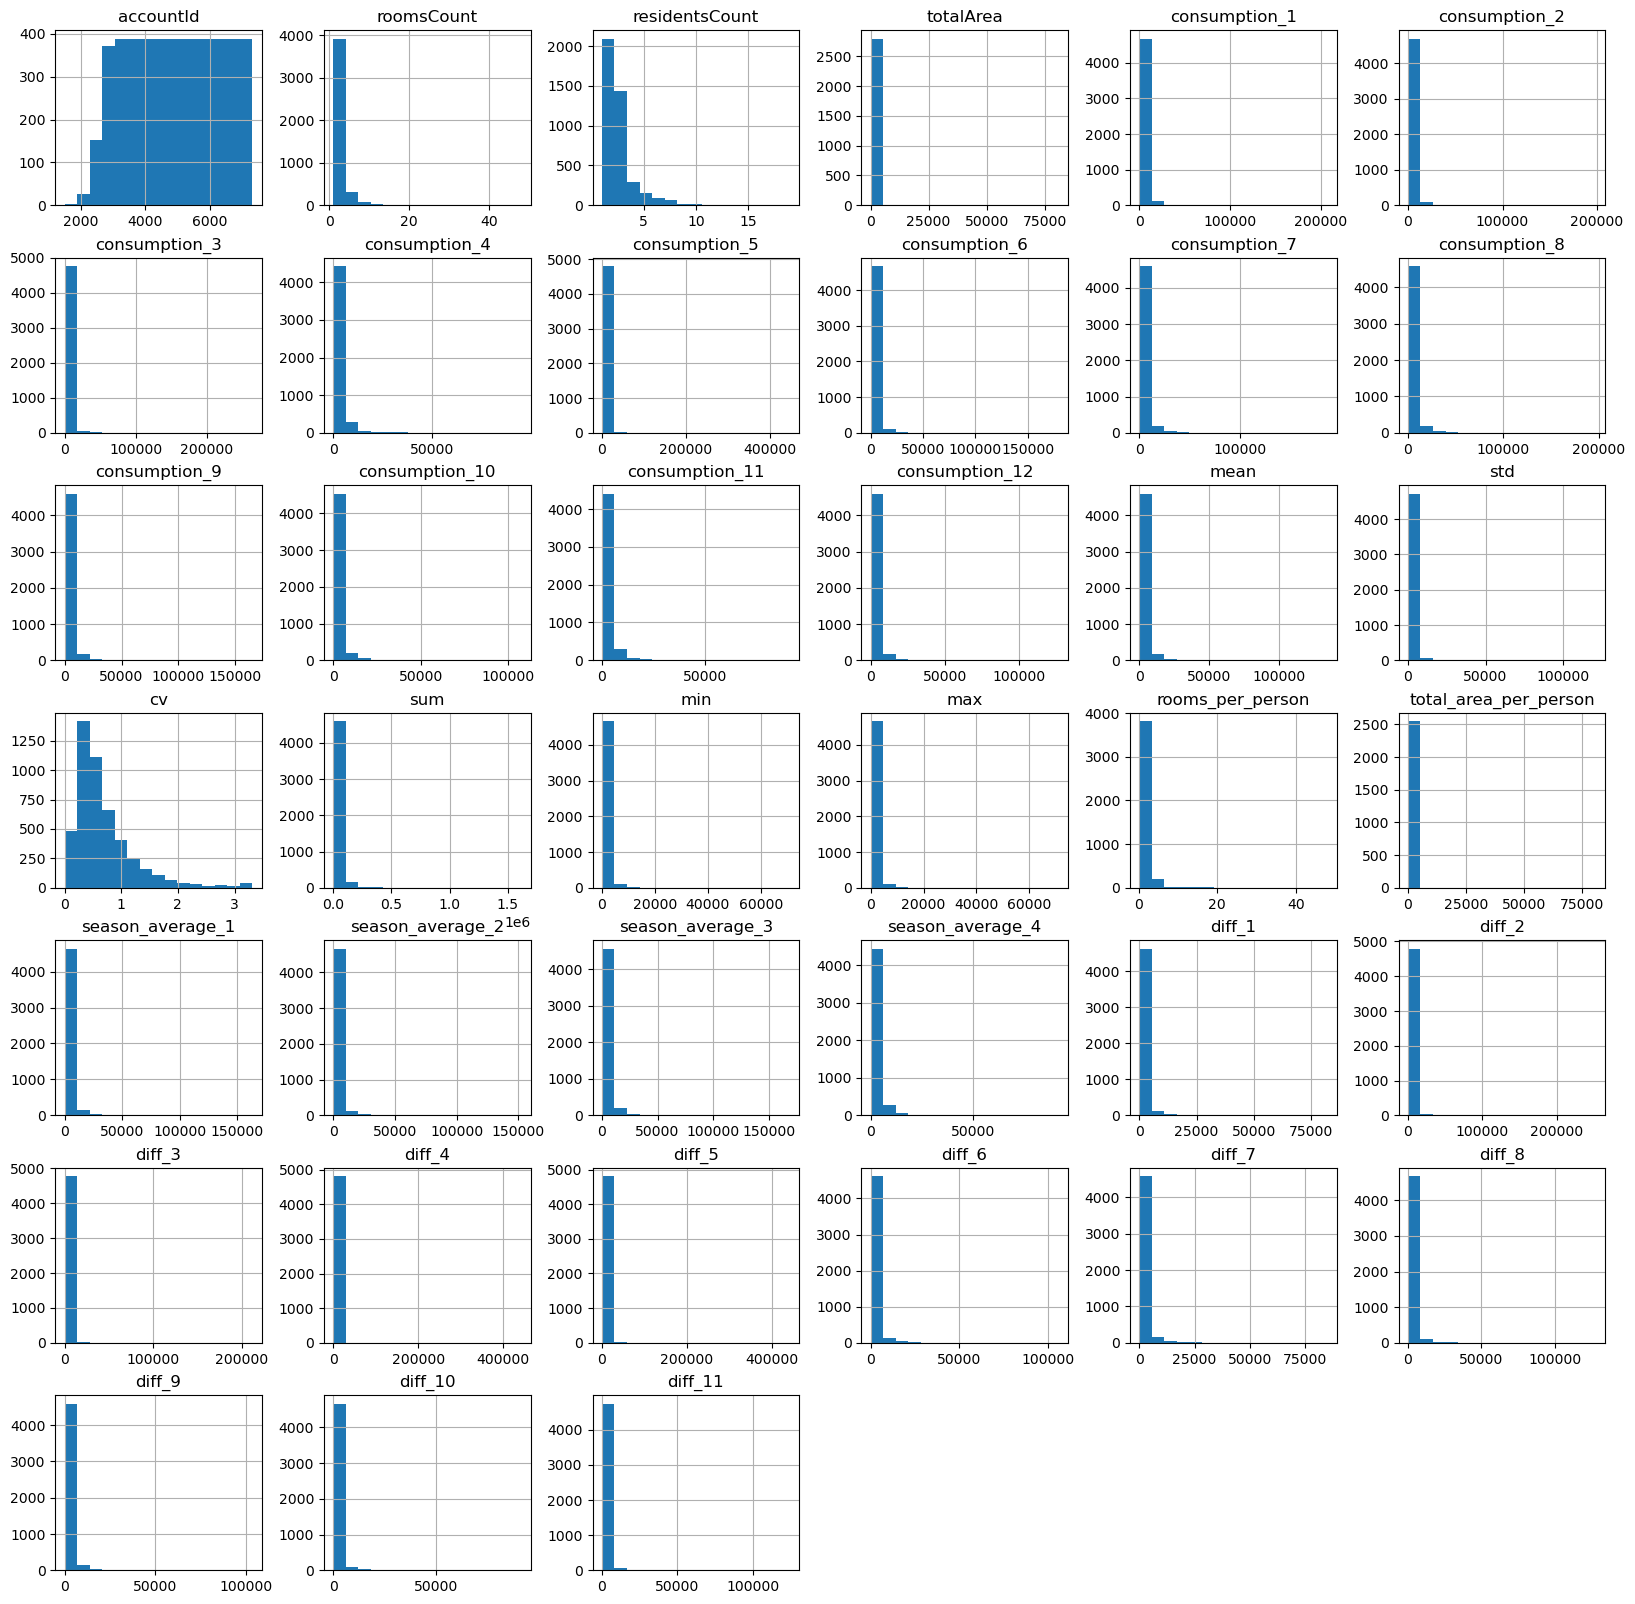

In [138]:
train_df.hist(figsize=(20,20), bins=15)
plt.show()

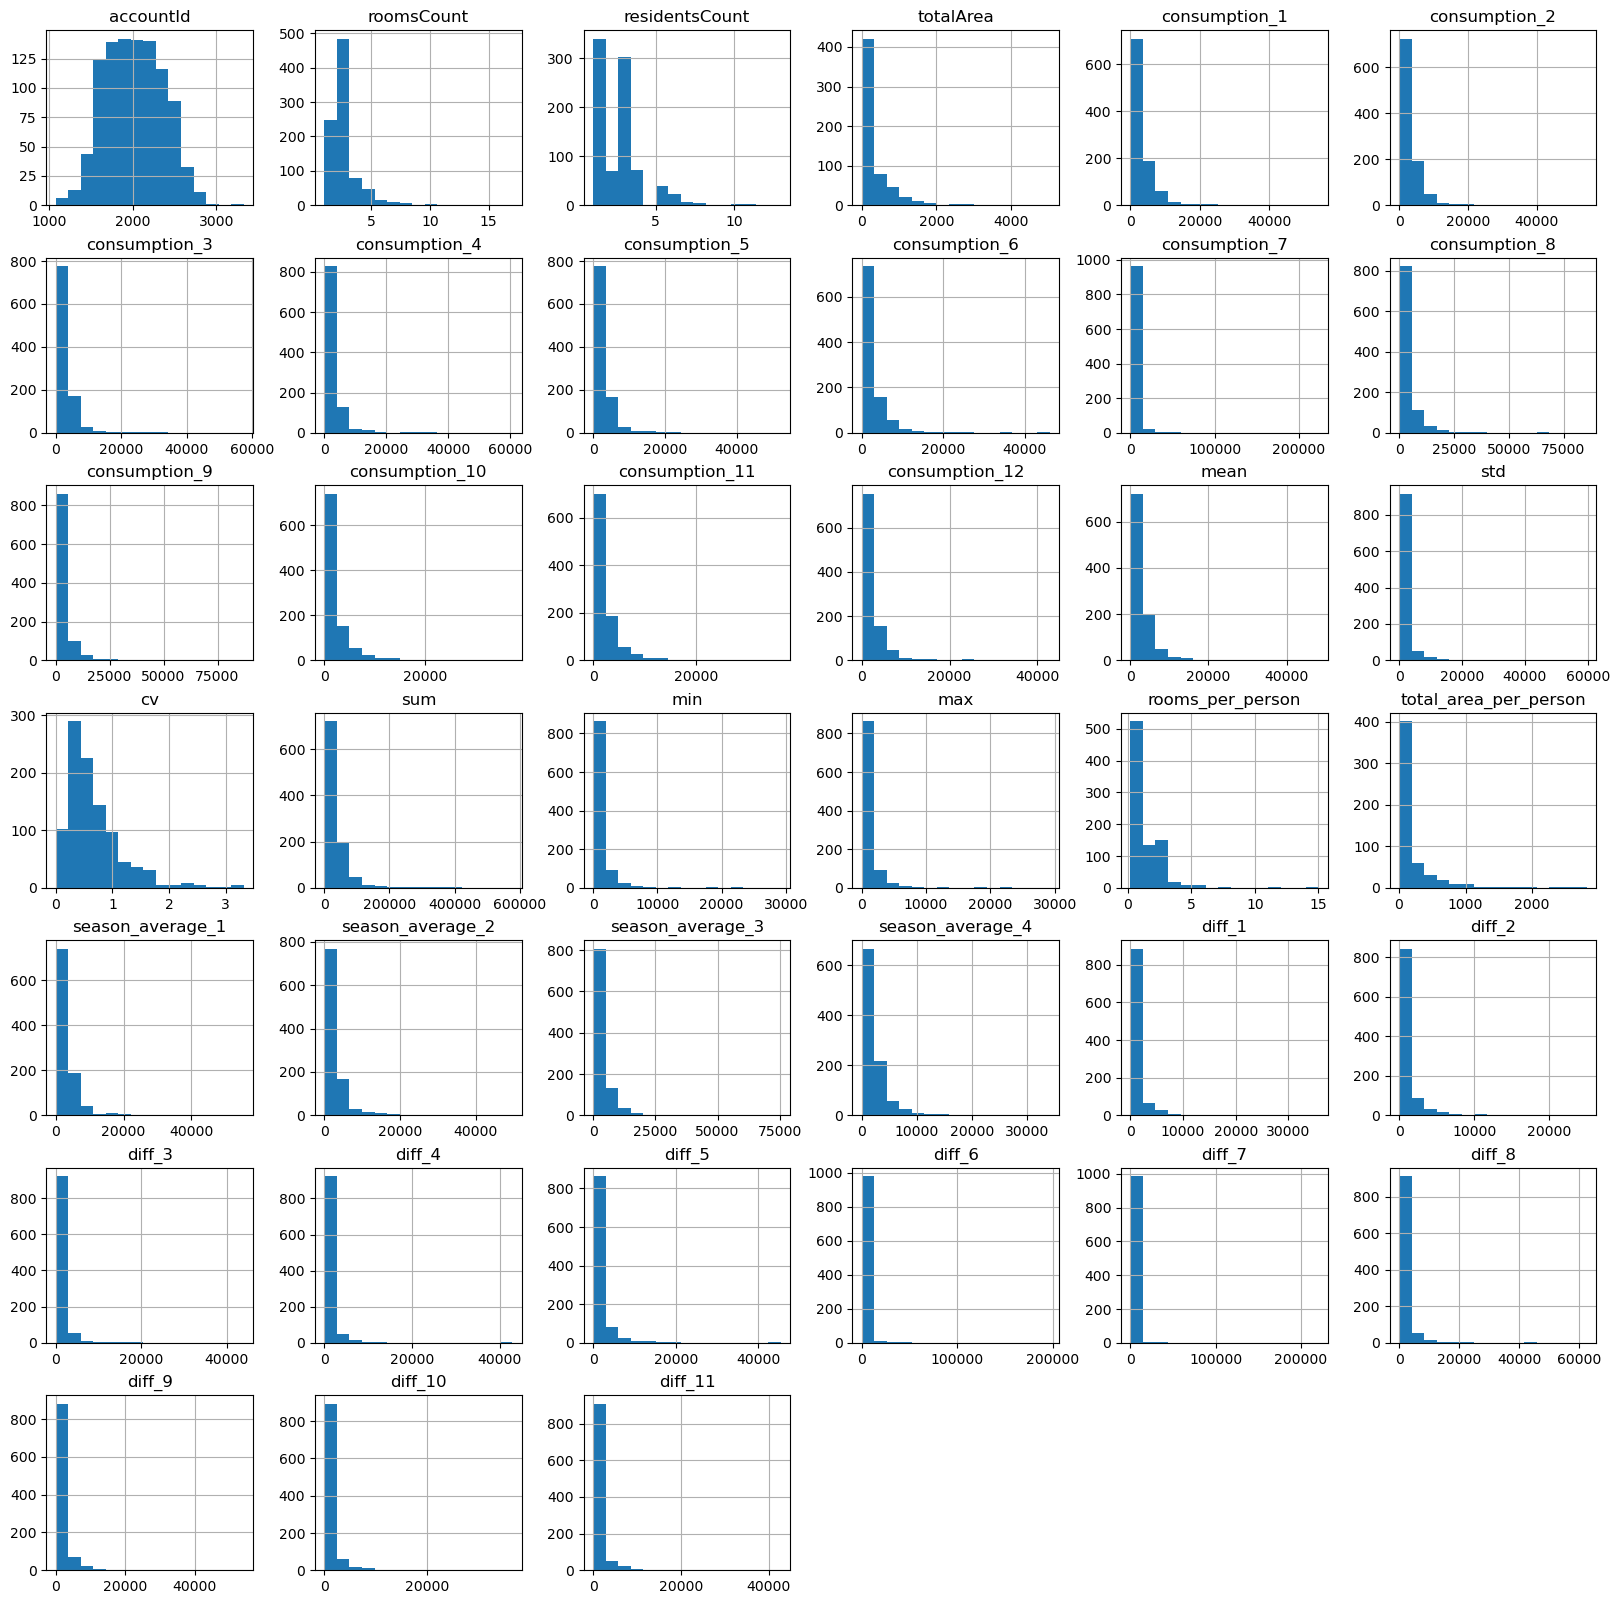

In [139]:
test_df.hist(figsize=(20,20), bins=15)
plt.show()

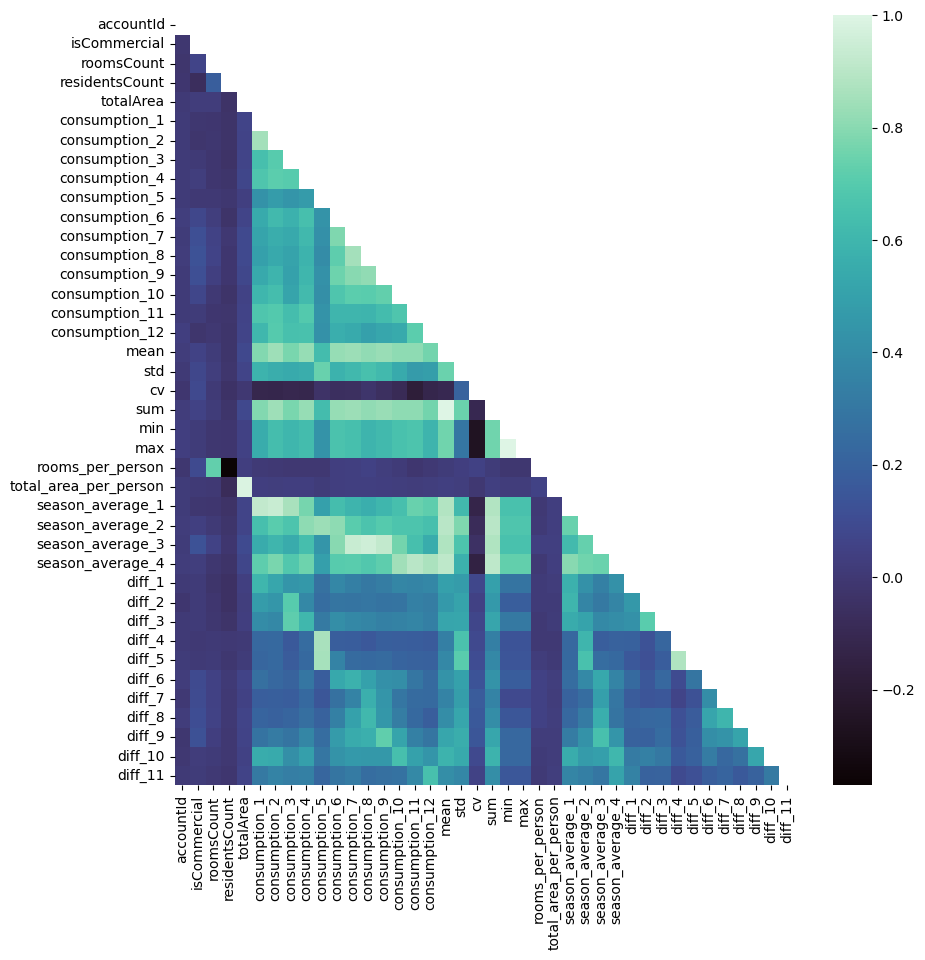

In [140]:
plt.figure(figsize=(10, 10))
colums = list(train_df)
colums.remove('address')
colums.remove('buildingType')

mask = np.triu(train_df.loc[:,colums].corr())
sns.heatmap(train_df.loc[:,colums].corr(), cmap="mako", mask=mask)
plt.show()

In [141]:
train_df.describe()

,accountId,roomsCount,residentsCount,totalArea,consumption_1,consumption_2,consumption_3,consumption_4,consumption_5,consumption_6,...,diff_2,diff_3,diff_4,diff_5,diff_6,diff_7,diff_8,diff_9,diff_10,diff_11
count,4826.000000,4343.000000,4159.000000,2800.000000,4826.000000,4826.000000,4826.000000,4826.000000,4826.000000,4826.000000,...,4826.000000,4826.000000,4826.000000,4826.000000,4826.000000,4826.000000,4826.000000,4826.000000,4826.000000,4826.000000
mean,4907.400746,3.026019,2.412840,369.281486,3337.096353,3103.583920,2835.427269,2598.785951,2746.641939,2813.495856,...,1205.457522,1174.028802,1116.592002,1735.388935,1584.556569,1414.399917,1539.153543,1632.484459,1253.552632,1108.519892
std,1404.220720,2.163091,1.627398,1618.833268,6935.721019,6511.844375,6624.400615,5105.491535,8398.493148,6025.235369,...,4922.281477,4602.211533,7392.829984,7747.235093,4051.691511,3903.409456,4415.590501,4221.993417,3415.997201,3314.045457
min,1497.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3707.250000,2.000000,1.000000,59.300000,445.000000,413.250000,404.250000,394.000000,414.250000,393.250000,...,69.000000,62.000000,63.000000,154.000000,105.000000,69.000000,89.000000,100.000000,76.250000,66.000000
50%,4913.500000,3.000000,2.000000,138.700000,1564.000000,1450.000000,1355.500000,1238.500000,1322.000000,1267.000000,...,336.000000,305.000000,299.000000,600.000000,450.500000,318.000000,413.000000,472.000000,367.500000,307.500000
75%,6119.750000,3.000000,3.000000,411.850000,4106.750000,3914.000000,3477.750000,3095.000000,3292.500000,3410.500000,...,1048.500000,978.000000,963.750000,1806.750000,1525.500000,1251.000000,1388.000000,1492.250000,1238.750000,1000.000000
max,7326.000000,48.000000,19.000000,80895.000000,206975.000000,198660.000000,264600.000000,94778.000000,446670.000000,179280.000000,...,252600.000000,211800.000000,441928.000000,441209.000000,106080.000000,85039.000000,128043.000000,103800.000000,91058.000000,124500.000000


In [142]:
train_df['totalArea'].max()

np.float64(80895.0)

In [143]:
train_df['totalArea'].min()

np.float64(1.0)

In [144]:
"""
train_df['roomsCount'] = train_df['roomsCount'].fillna(0)
train_df['residentsCount'] = train_df['residentsCount'].fillna(0)
train_df['totalArea'] = train_df['totalArea'].fillna(0)
train_df['rooms_per_person'] = train_df['rooms_per_person'].fillna(0)
train_df['total_area_per_person'] = train_df['total_area_per_person'].fillna(0)

test_df['roomsCount'] = test_df['roomsCount'].fillna(0)
test_df['residentsCount'] = test_df['residentsCount'].fillna(0)
test_df['totalArea'] = test_df['totalArea'].fillna(0)
test_df['rooms_per_person'] = test_df['rooms_per_person'].fillna(0)
test_df['total_area_per_person'] = test_df['total_area_per_person'].fillna(0)
"""

"\ntrain_df['roomsCount'] = train_df['roomsCount'].fillna(0)\ntrain_df['residentsCount'] = train_df['residentsCount'].fillna(0)\ntrain_df['totalArea'] = train_df['totalArea'].fillna(0)\ntrain_df['rooms_per_person'] = train_df['rooms_per_person'].fillna(0)\ntrain_df['total_area_per_person'] = train_df['total_area_per_person'].fillna(0)\n\ntest_df['roomsCount'] = test_df['roomsCount'].fillna(0)\ntest_df['residentsCount'] = test_df['residentsCount'].fillna(0)\ntest_df['totalArea'] = test_df['totalArea'].fillna(0)\ntest_df['rooms_per_person'] = test_df['rooms_per_person'].fillna(0)\ntest_df['total_area_per_person'] = test_df['total_area_per_person'].fillna(0)\n"

In [145]:
X_train = train_df.drop([
    'accountId',
    'isCommercial',
    'address',
    #'consumption_1',
    #'consumption_2',
    #'consumption_3',
    #'consumption_4',
    #'consumption_5',
    #'consumption_6',
    #'consumption_7',
    #'consumption_8',
    #'consumption_9',
    #'consumption_10',
    #'consumption_11',
    #'consumption_12',
    #'season_average_1',
    #'season_average_2',
    #'season_average_3',
    #'season_average_4',
    #'mean',
    #'std',
    #'sum',
], axis=1)
y_train = train_df["isCommercial"]

X_test = test_df.drop([
    'accountId',
    'isCommercial',
    'address',
    #'consumption_1',
    #'consumption_2',
    #'consumption_3',
    #'consumption_4',
    #'consumption_5',
    #'consumption_6',
    #'consumption_7',
    #'consumption_8',
    #'consumption_9',
    #'consumption_10',
    #'consumption_11',
    #'consumption_12',
    #'season_average_1',
    #'season_average_2',
    #'season_average_3',
    #'season_average_4',
    #'mean',
    #'std',
    #'sum',
], axis=1)

y_test = test_df["isCommercial"]

In [146]:
categorical_features = ['buildingType']
numerical_features = [
    'roomsCount',
    'residentsCount',
    'totalArea',
    'rooms_per_person',
    'total_area_per_person',
    'diff_1',
    'diff_2',
    'diff_3',
    'diff_4',
    'diff_5',
    'diff_6',
    'diff_7',
    'diff_8',
    'diff_9',
    'diff_10',
    'diff_11',
    'cv',
    'min',
    'max',
]

In [172]:
categorical_features_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown="ignore"),
)

In [173]:
classifier_transformer = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), numerical_features),
        ('cat', categorical_features_pipeline, categorical_features),
    ],
    force_int_remainder_cols=False,
    remainder="drop",
)

In [174]:
random_forest_model_depth_100 = Pipeline(steps=[
    ('preprocessor', classifier_transformer),
    ('smote', SMOTE()),
    ('classifier', RandomForestClassifier(criterion='entropy', n_estimators=10**3, max_depth=100, min_samples_split=5)),
])

In [175]:
random_forest_model_depth_100.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   transformers=[('num', SimpleImputer(),
                                                  ['roomsCount',
                                                   'residentsCount',
                                                   'totalArea',
                                                   'rooms_per_person',
                                                   'total_area_per_person',
                                                   'diff_1', 'diff_2', 'diff_3',
                                                   'diff_4', 'diff_5', 'diff_6',
                                                   'diff_7', 'diff_8', 'diff_9',
                                                   'diff_10', 'diff_11', 'cv',
                                                   'min', 'max']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['buildingType'])])),
                ('smote', SMOTE()),
                ('classifier',
                 RandomForestClassifier(criterion='entropy', max_depth=100,
                                        min_samples_split=5,
                                        n_estimators=1000))])

In [176]:
y_pred = random_forest_model_depth_100.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.75      0.80      0.77       608
        True       0.65      0.58      0.61       392

    accuracy                           0.71      1000
   macro avg       0.70      0.69      0.69      1000
weighted avg       0.71      0.71      0.71      1000



In [152]:
class_weights={0: 1, 1: 1.5}
# auto_class_weights='Balanced',

catboost_model = Pipeline([
    ('preprocessor', classifier_transformer),
    ('smote', SMOTE()),
    ('clf', CatBoostClassifier(iterations=10**4, depth=6, learning_rate=10**(-4), verbose=0, l2_leaf_reg=5, class_weights=class_weights, loss_function='Logloss'))
])

catboost_model.fit(X_train, y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   transformers=[('num', SimpleImputer(),
                                                  ['roomsCount',
                                                   'residentsCount',
                                                   'totalArea',
                                                   'rooms_per_person',
                                                   'total_area_per_person',
                                                   'diff_1', 'diff_2', 'diff_3',
                                                   'diff_4', 'diff_5', 'diff_6',
                                                   'diff_7', 'diff_8', 'diff_9',
                                                   'diff_10', 'diff_11', 'cv',
                                                   'min', 'max']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['buildingType'])])),
                ('smote', SMOTE()),
                ('clf',
                 <catboost.core.CatBoostClassifier object at 0x70e8c39a8230>)])

In [153]:
y_pred = catboost_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.81      0.50      0.62       608
        True       0.51      0.82      0.63       392

    accuracy                           0.63      1000
   macro avg       0.66      0.66      0.63      1000
weighted avg       0.70      0.63      0.62      1000



In [191]:
bagging_classifier = Pipeline([
    ('preprocessor', classifier_transformer),
    ('smote', SMOTE()),
    ('clf', BaggingClassifier(n_estimators=1000, random_state=0))
])
bagging_classifier.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   transformers=[('num', SimpleImputer(),
                                                  ['roomsCount',
                                                   'residentsCount',
                                                   'totalArea',
                                                   'rooms_per_person',
                                                   'total_area_per_person',
                                                   'diff_1', 'diff_2', 'diff_3',
                                                   'diff_4', 'diff_5', 'diff_6',
                                                   'diff_7', 'diff_8', 'diff_9',
                                                   'diff_10', 'diff_11', 'cv',
                                                   'min', 'max']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['buildingType'])])),
                ('smote', SMOTE()),
                ('clf', BaggingClassifier(n_estimators=1000, random_state=0))])

In [192]:
y_pred = bagging_classifier.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.74      0.78      0.76       608
        True       0.63      0.58      0.60       392

    accuracy                           0.70      1000
   macro avg       0.69      0.68      0.68      1000
weighted avg       0.70      0.70      0.70      1000



In [ ]:
numerical_features_nn = X_train.select_dtypes(include=np.number).columns
categorical_features_nn = X_train.select_dtypes(exclude=np.number).columns

preprocessor_nn = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),  # Заполняем медианой
            ("scaler", StandardScaler())                    # Масштабируем
        ]), numerical_features_nn),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),  # Заполняем модой
            ("encoder", OneHotEncoder(handle_unknown="ignore"))  # sparse=False для pandas
        ]), categorical_features_nn)
    ],
)

In [187]:
class KerasNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, epochs=20, learning_rate=0.1, batch_size=32, verbose=0):
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.verbose = verbose
        self.classes_ = None
        self.model = self._build_model()

        
    def _build_model(self, input_dim=None):
        model = Sequential()
        if input_dim:
            model.add(Input(shape=(input_dim,)),)

        model.add(BatchNormalization())
        model.add(Dense(
            units=128,
            activation=LeakyReLU(negative_slope=0.2)
        ))
        model.add(Dropout(0.3))

        model.add(BatchNormalization())
        model.add(Dense(
            units=64,
            activation=LeakyReLU(negative_slope=0.2)
        ))
        model.add(Dropout(0.2))

        model.add(BatchNormalization())
        model.add(Dense(
            units=32,
            activation=LeakyReLU(negative_slope=0.2)
        ))
        model.add(Dropout(0.2))

        model.add(BatchNormalization())
        model.add(Dense(
            units=16,
            activation=LeakyReLU(negative_slope=0.2)
        ))
        model.add(Dropout(0.2))
        
        model.add(Dense(1, activation="sigmoid"))
        
        model.compile(
            optimizer=Adam(learning_rate=self.learning_rate),
            loss="binary_crossentropy",
        )
        return model

    
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        
        if not hasattr(self.model.layers[0], 'input_shape'):
            self.model = self._build_model(input_dim=X.shape[1])
        
        self.model.fit(
            X, y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose
        )
        return self

    
    def predict(self, X):
        return (self.model.predict(X) > 0.5).astype(int)

    
    def predict_proba(self, X):
        return self.model.predict(X)

    def score(self, X, y):
        return self.model.evaluate(X, y, verbose=0)[1] 

In [188]:
model_nn_pipeline = make_pipeline(
    preprocessor_nn,
    SMOTE(),
    KerasNNClassifier(epochs=10**3, learning_rate=10e-3, batch_size=32, verbose=0),
)

In [189]:
model_nn_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['roomsCount', 'residentsCount', 'totalArea', 'consumption_1',
       'consumption_2', 'consumption_3', 'consumption_4', 'consumption_5',
       'consumption_6', 'consumption_7', 'consumption_8', 'consu...
       'season_average_4', 'diff_1', 'diff_2', 'diff_3', 'diff_4', 'diff_5',
       'diff_6', 'diff_7', 'diff_8', 'diff_9', 'diff_10', 'diff_11'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['buildingType'], dtype='object'))])),
                ('smote', SMOTE()),
                ('kerasnnclassifier',
                 KerasNNClassifier(epochs=1000, learning_rate=0.01))])

In [190]:
y_pred = model_nn_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

       False       0.82      0.43      0.56       608
        True       0.49      0.85      0.62       392

    accuracy                           0.59      1000
   macro avg       0.65      0.64      0.59      1000
weighted avg       0.69      0.59      0.58      1000



In [193]:
# Создаем ансамбль из CatBoost и нескольких нейросетей
estimators = [
    ("catboost", catboost_model),
    #("rand_forest_100", random_forest_model_depth_100),
    #('bagging', bagging_classifier),
    ("nn1", model_nn_pipeline),
]

stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

In [194]:
stacking_model.fit(X_train, y_train)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


StackingClassifier(cv=5,
                   estimators=[('catboost',
                                Pipeline(steps=[('preprocessor',
                                                 ColumnTransformer(force_int_remainder_cols=False,
                                                                   transformers=[('num',
                                                                                  SimpleImputer(),
                                                                                  ['roomsCount',
                                                                                   'residentsCount',
                                                                                   'totalArea',
                                                                                   'rooms_per_person',
                                                                                   'total_area_per_person',
                                                                                   'diff_1',
                                                                                   'diff_2',
                                                                                   'diff_3',
                                                                                   'diff_4',
                                                                                   'diff_5',
                                                                                   'diff_6',
                                                                                   'diff_7',
                                                                                   'diff_8',
                                                                                   'diff_9',
                                                                                   'diff_10',
                                                                                   'diff_1...
       'diff_6', 'diff_7', 'diff_8', 'diff_9', 'diff_10', 'diff_11'],
      dtype='object')),
                                                                                 ('cat',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='most_frequent')),
                                                                                                  ('encoder',
                                                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                                                  Index(['buildingType'], dtype='object'))])),
                                                ('smote', SMOTE()),
                                                ('kerasnnclassifier',
                                                 KerasNNClassifier(epochs=1000,
                                                                   learning_rate=0.01))]))],
                   final_estimator=LogisticRegression())

In [195]:
y_pred = stacking_model.predict(X_test)
print(classification_report(y_test, y_pred))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

       False       0.70      0.82      0.76       608
        True       0.62      0.44      0.52       392

    accuracy                           0.68      1000
   macro avg       0.66      0.63      0.64      1000
weighted avg       0.67      0.68      0.66      1000



Было с nn:
              precision    recall  f1-score   support

       False       0.74      0.86      0.79       608
        True       0.70      0.52      0.60       392

    accuracy                           0.72      1000
   macro avg       0.72      0.69      0.69      1000
weighted avg       0.72      0.72      0.72      1000

In [ ]:
columns = X_test.loc[0].index

X_test_only_one = X_test # pd.DataFrame([X_test.loc[0]], columns=columns)

probbility = stacking_model.predict_proba(X_test_only_one)
print(probbility)
print(len(probbility))
np.savetxt("probbility_control.csv", probbility, delimiter=",")


In [185]:
def pipeline_to_file(pipeline, file=None):
    if file is not None:
        with open(file, "wb") as f:
          pickle.dump(pipeline, f)
    else:
        return pickle.dumps(pipeline)


def file_to_pipeline(file):
    return pickle.load(file)

In [186]:
pipeline_to_file(stacking_model, 'model_object')

In [57]:
print(type(stacking_model))

<class 'sklearn.ensemble._stacking.StackingClassifier'>


In [ ]:
!tar -cf /content/catboost.tar /content/catboost_info/


In [ ]:
from google.colab import files
files.download("/content/catboost.tar")

In [ ]:
control_df = pd.read_json('dataset_control.json')

In [21]:
control_df = upnack_consumption(control_df)
control_df['mean'] = control_df.loc[:,'consumption_1':'consumption_12'].apply(mean_consumption, axis=1)
control_df['std'] = control_df.loc[:,'consumption_1':'consumption_12'].apply(std_consumption, axis=1)
control_df['cv'] = control_df.loc[:,'consumption_1':'consumption_12'].apply(coefficient_of_variation, axis=1)
control_df['sum'] = test_df.loc[:,'consumption_1':'consumption_12'].apply(sum_consumption, axis=1)
control_df['min'] = control_df.loc[:,'consumption_1':'consumption_12'].apply(min_consumption, axis=1)
control_df['max'] =control_df.loc[:,'consumption_1':'consumption_12'].apply(min_consumption, axis=1)
control_df['rooms_per_person'] = control_df['roomsCount'].div(control_df['residentsCount'])
control_df['total_area_per_person'] = control_df['totalArea'].div(control_df['residentsCount'])
control_df = average_for_season(control_df)
control_df = diff_two_mounth(control_df)

NameError: name 'control_df' is not defined